# 02｜驗證、正則化與早停

第一週補充；對應 `01_機器學習概觀.md` 的欠擬合／過擬合與正則化。課堂選看前兩段約 20 分鐘，早停與偏差–變異數留課後。

## 來源與改編界線
- [leonjyentub/MachineLearning2025 / 02_Polynomial_Regression_overfitting.ipynb](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/02_Polynomial_Regression_overfitting.ipynb)：儲存格 1–3 的二次資料與 degree 2 / 16
- [leonjyentub/MachineLearning2025 / 02_Regularization_Regression.ipynb](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/02_Regularization_Regression.ipynb)：PolynomialFeatures、StandardScaler、Ridge／Lasso
- [leonjyentub/MachineLearning2025 / 02_Polynomial_Regression_Early_stopping.ipynb](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/02_Polynomial_Regression_Early_stopping.ipynb)：partial_fit、每 epoch 誤差與最佳模型保存
- [ageron/handson-mlp / 04_training_linear_models.ipynb](https://github.com/ageron/handson-mlp/blob/47eba45aacc85feae51ba7db68dd1ca66cb25e0a/04_training_linear_models.ipynb)：Learning Curves、Regularized Linear Models、Early Stopping 章節

**本課程修改／補充：** 沿用二次資料生成思路，增加獨立 train/validation/test；所有候選在相同 CV folds 比較。正則化使用 12 次多項式以控制數值條件；早停恢復最佳 checkpoint。另補一格對齊投影片「正則化快算」的 (3,0)／(1.5,1.5) L1／L2 驗算。新實驗數字不能替換原 PPTX 報告值。

來源固定至上述 commit；原檔保留於 `../upstream/`，逐檔 SHA-256 見 `../upstream/manifest.json`。Géron 程式依 Apache-2.0 改編，授權原文保留。儲存格索引從 0 起算。圖表與數值是本 Notebook 重跑結果，不能直接當成書中成效。

從第一格依序執行；各本可獨立重跑。Python 環境與資料準備見 [操作說明](../README.md)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

In [2]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone
rng = np.random.default_rng(SEED)
X = rng.uniform(-5,5,size=(180,1))
y = .5*X[:,0]**2-X[:,0]+2+rng.normal(0,3,len(X))
X_dev,X_test,y_dev,y_test = train_test_split(X,y,test_size=.2,random_state=SEED)
X_train,X_val,y_train,y_val = train_test_split(X_dev,y_dev,test_size=.25,random_state=SEED)
folds = list(KFold(5,shuffle=True,random_state=SEED).split(X_train))
print('train / validation / test:',len(X_train),len(X_val),len(X_test))
def poly_model(degree, estimator):
    return make_pipeline(PolynomialFeatures(degree,include_bias=False),StandardScaler(),estimator)

train / validation / test: 108 36 36


## 1. 同一批資料，改變複雜度
先畫訓練點與已知生成函數，再比較 training RMSE 和 5-fold CV RMSE。CV 每折重新 fit 多項式後的縮放器。

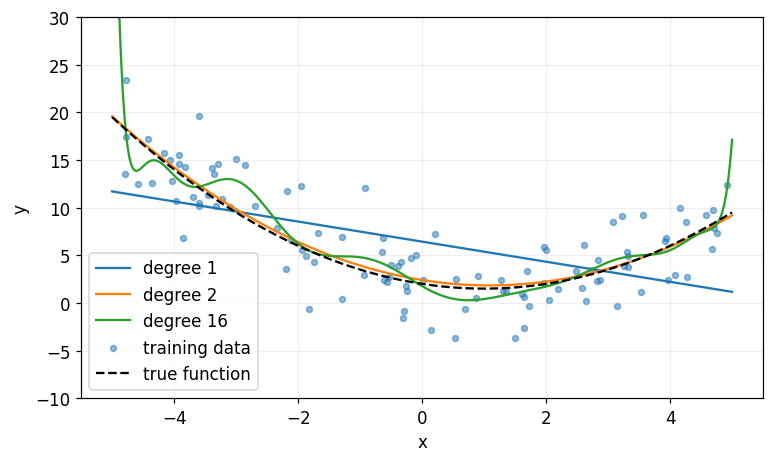

,degree,train_RMSE,CV_RMSE_mean,CV_RMSE_sd
0,1,4.577528,4.643568,0.964016
1,2,2.998631,3.161724,0.244873
2,16,2.809885,4.167049,1.678580


In [3]:
grid = np.linspace(-5,5,400).reshape(-1,1)
rows=[]
for degree in [1,2,16]:
    model = poly_model(degree,LinearRegression()).fit(X_train,y_train)
    cv = -cross_val_score(model,X_train,y_train,cv=folds,scoring='neg_root_mean_squared_error')
    rows.append({'degree':degree,'train_RMSE':root_mean_squared_error(y_train,model.predict(X_train)),
                 'CV_RMSE_mean':cv.mean(),'CV_RMSE_sd':cv.std(ddof=1)})
    plt.plot(grid,model.predict(grid),label=f'degree {degree}')
plt.scatter(X_train,y_train,s=15,alpha=.5,label='training data')
plt.plot(grid,.5*grid**2-grid+2,'k--',label='true function')
plt.ylim(-10,30);plt.xlabel('x');plt.ylabel('y');plt.legend()
savefig('02_model_complexity')
pd.DataFrame(rows)

## 2. 固定 degree，改變正則化
`PolynomialFeatures → StandardScaler → estimator`。L1 可產生零係數，L2 通常連續縮小係數；不同懲罰的 alpha 不代表相同強度。以下依 CV RMSE 選候選，驗證集留給下一段早停。

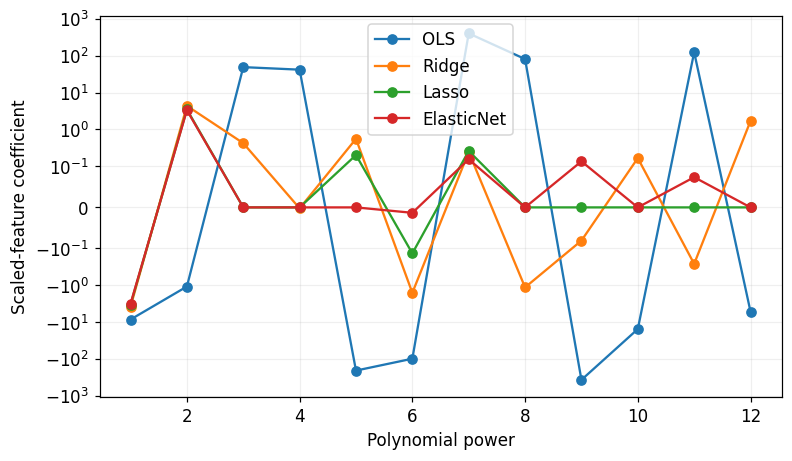

,model,CV_RMSE,coefficient_L2_norm,near_zero_coefficients
1,Ridge,3.182865,6.409720,0
3,ElasticNet,3.215419,4.604230,6
2,Lasso,3.215893,4.840578,7
0,OLS,3.448076,610.331749,0


In [4]:
candidates = {'OLS':LinearRegression(), 'Ridge':Ridge(alpha=1),
              'Lasso':Lasso(alpha=.05,max_iter=100000,tol=1e-4),
              'ElasticNet':ElasticNet(alpha=.05,l1_ratio=.5,max_iter=100000,tol=1e-4)}
reg_rows=[]; fitted={}
for name,estimator in candidates.items():
    pipe=poly_model(12,estimator).fit(X_train,y_train)
    fitted[name]=pipe
    cv=-cross_val_score(pipe,X_train,y_train,cv=folds,scoring='neg_root_mean_squared_error')
    coef=pipe[-1].coef_
    reg_rows.append({'model':name,'CV_RMSE':cv.mean(),'coefficient_L2_norm':np.linalg.norm(coef),
                     'near_zero_coefficients':int(np.sum(np.abs(coef)<1e-8))})
    plt.plot(np.arange(1,13),coef,marker='o',label=name)
plt.yscale('symlog',linthresh=.1);plt.xlabel('Polynomial power');plt.ylabel('Scaled-feature coefficient');plt.legend()
savefig('02_regularization_coefficients')
reg_table=pd.DataFrame(reg_rows).sort_values('CV_RMSE')
reg_table

## 補充：正則化快算

對應投影片「快算：不同係數如何受到懲罰」。兩個模型的 MSE 都是 2、特徵同尺度，比較係數向量 $(3,0)$ 與 $(1.5,1.5)$ 在 $\lambda=1$、$J=\mathrm{MSE}+\lambda\Omega$ 下的懲罰與總目標。這只是兩組固定係數的比較，不足以證明 L1 一定得到稀疏解；稀疏性的幾何直覺見投影片。

In [5]:
coef_sets={'A (3, 0)':np.array([3.,0.]),'B (1.5, 1.5)':np.array([1.5,1.5])}
penalty=pd.DataFrame({name:{'L1':np.abs(c).sum(),'L2':np.sum(c**2)} for name,c in coef_sets.items()}).T
penalty['J_with_L1']=2+penalty.L1
penalty['J_with_L2']=2+penalty.L2
assert penalty.L1.tolist()==[3.,3.] and penalty.L2.tolist()==[9.,4.5]
assert penalty.J_with_L2.tolist()==[11.,6.5]
penalty

,L1,L2,J_with_L1,J_with_L2
"A (3, 0)",3.0,9.0,5.0,11.0
"B (1.5, 1.5)",3.0,4.5,5.0,6.5


## 3. 早停：每個 epoch 看 validation，保存並恢復最佳狀態

這裡使用整批資料的一次 `partial_fit` 作為一個 epoch；SGD 在其中逐筆更新。最大 1,200 epochs、patience 80、以驗證 RMSE 嚴格改善為準，規則在看曲線前固定。不同資料不一定出現明顯 U 形；沒有觸發早停也應照實報告。

原範例把 `X_test` 用於選 epoch；本版改用 validation，真正 test 最後才讀取評估。

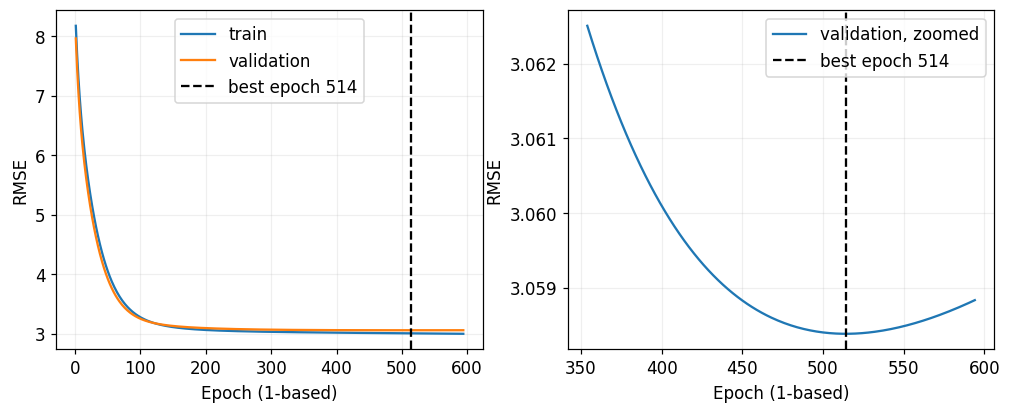

Executed epochs: 594 best epoch (1-based): 514 patience triggered: True


In [6]:
import copy
preprocess=make_pipeline(PolynomialFeatures(12,include_bias=False),StandardScaler())
Z_train=preprocess.fit_transform(X_train)
Z_val=preprocess.transform(X_val)
sgd=SGDRegressor(penalty=None,learning_rate='constant',eta0=.0002,random_state=SEED)
best_loss=np.inf; best_epoch=-1; best_model=None; patience=80
curve=[]
for epoch in range(1200):
    sgd.partial_fit(Z_train,y_train)
    tr=root_mean_squared_error(y_train,sgd.predict(Z_train))
    va=root_mean_squared_error(y_val,sgd.predict(Z_val))
    curve.append((tr,va))
    if va < best_loss:
        best_loss=va;best_epoch=epoch;best_model=copy.deepcopy(sgd)
    if epoch-best_epoch >= patience:
        break
curve=np.asarray(curve)
assert np.isclose(root_mean_squared_error(y_val,best_model.predict(Z_val)),curve[:,1].min())
epochs=np.arange(1,len(curve)+1)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(epochs,curve[:,0],label='train');axes[0].plot(epochs,curve[:,1],label='validation')
zoom_start=max(0,best_epoch-160)
axes[1].plot(epochs[zoom_start:],curve[zoom_start:,1],label='validation, zoomed')
for ax in axes:
    ax.axvline(best_epoch+1,color='k',ls='--',label=f'best epoch {best_epoch+1}')
    ax.set(xlabel='Epoch (1-based)',ylabel='RMSE');ax.legend()
savefig('02_early_stopping')
print('Executed epochs:',len(curve),'best epoch (1-based):',best_epoch+1,
      'patience triggered:',epoch-best_epoch>=patience)

## 4. 最後一次開啟 test
兩條事先指定的流程：CV 選出的正則化候選、validation 選出的早停 checkpoint。測試結果只報告，不反過來改 alpha 或 epoch。這是小型教學比較，不能推論某方法普遍勝出。

In [7]:
chosen_name=reg_table.iloc[0]['model']
chosen=clone(fitted[chosen_name]).fit(X_dev,y_dev)
test_results={'CV_selected_model':chosen_name,
              'CV_selected_test_RMSE':root_mean_squared_error(y_test,chosen.predict(X_test)),
              'early_stopped_test_RMSE':root_mean_squared_error(y_test,best_model.predict(preprocess.transform(X_test))),
              'best_epoch':best_epoch+1,'epochs_executed':len(curve)}
report('regularization',test_results)
pd.Series(test_results)

CV_selected_model             Ridge
CV_selected_test_RMSE       2.76219
early_stopped_test_RMSE    2.764103
best_epoch                      514
epochs_executed                 594
dtype: object

## 5. 選做：把偏差與變異數數據化

只有合成資料才知道真函數。重複抽取 80 組訓練資料；在同一網格上分解平方誤差：$E[(\hat f-f)^2]=bias^2+variance$。下圖不包含不可約觀測雜訊；若預測新帶雜訊 y，需再加噪音變異數 9。有限網格與有限重複次數僅為估計。

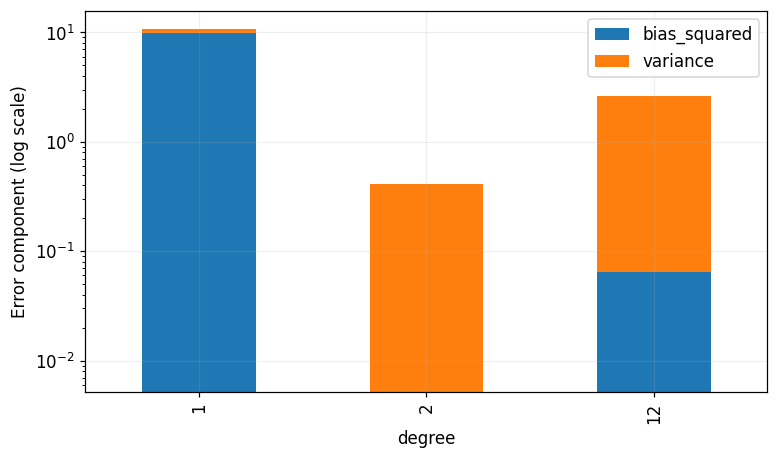

,bias_squared,variance,function_MSE
degree,,,
1,9.845957,0.878896,10.724854
2,0.005180,0.407653,0.412833
12,0.064564,2.546879,2.611442


In [8]:
rng=np.random.default_rng(SEED)
xgrid=np.linspace(-4.5,4.5,100).reshape(-1,1)
ftrue=.5*xgrid[:,0]**2-xgrid[:,0]+2
bv=[]
for degree in [1,2,12]:
    predictions=[]
    for _ in range(80):
        xs=rng.uniform(-5,5,(60,1));ys=.5*xs[:,0]**2-xs[:,0]+2+rng.normal(0,3,60)
        predictions.append(poly_model(degree,LinearRegression()).fit(xs,ys).predict(xgrid))
    predictions=np.array(predictions)
    bias2=np.mean((predictions.mean(axis=0)-ftrue)**2)
    variance=np.mean(predictions.var(axis=0))
    error=np.mean((predictions-ftrue)**2)
    assert np.isclose(error,bias2+variance)
    bv.append({'degree':degree,'bias_squared':bias2,'variance':variance,'function_MSE':error})
bv=pd.DataFrame(bv).set_index('degree')
bv[['bias_squared','variance']].plot.bar(stacked=True,logy=True)
plt.ylabel('Error component (log scale)');savefig('02_bias_variance')
bv

## 練習與參考答案

- 將正則化強度設成 0.001／1／100，在同一 CV folds 比較；執行新的探索後，原 test 已看過，不能再稱為全新獨立驗證。
- 若最後一輪模型與最佳模型不同，部署哪一個？**驗證集選中的 checkpoint。**
- 增加模型複雜度是否一定改善？**訓練誤差與泛化誤差的變化不相同。**